In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("car data.csv")

df.columns = df.columns.str.strip()

print("Dataset Shape")
print(df.shape)

print("\nMissing Values Count")
print(df.isnull().sum())

df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0].title())

current_year = 2026
df['Car_Age'] = current_year - df['Year']

print("\nCleaned DataFrame Preview")
df.head()

Dataset Shape
(301, 9)

Missing Values Count
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Cleaned DataFrame Preview


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Brand,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,Ritz,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,Sx4,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,Ciaz,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,Wagon,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,Swift,12


Statistical Summary


,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189,12.372093
std,2.891554,5.082812,8.644115,38886.883882,0.247915,2.891554
min,2003.000000,0.100000,0.320000,500.000000,0.000000,8.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000,10.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000,12.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000,14.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000,23.000000


C:\Users\admin\AppData\Local\Temp\ipykernel_1128\861946241.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')


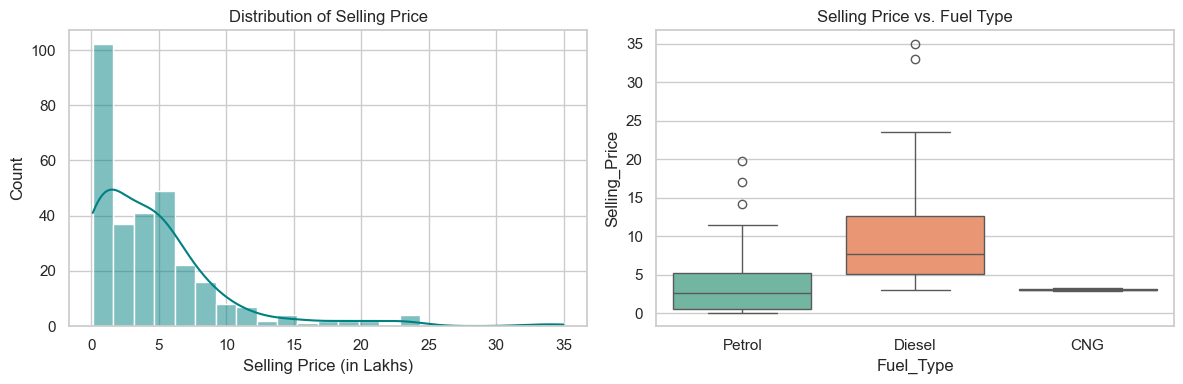

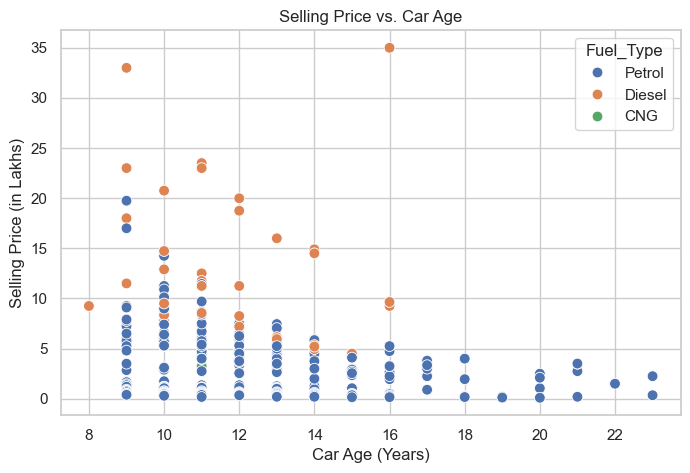

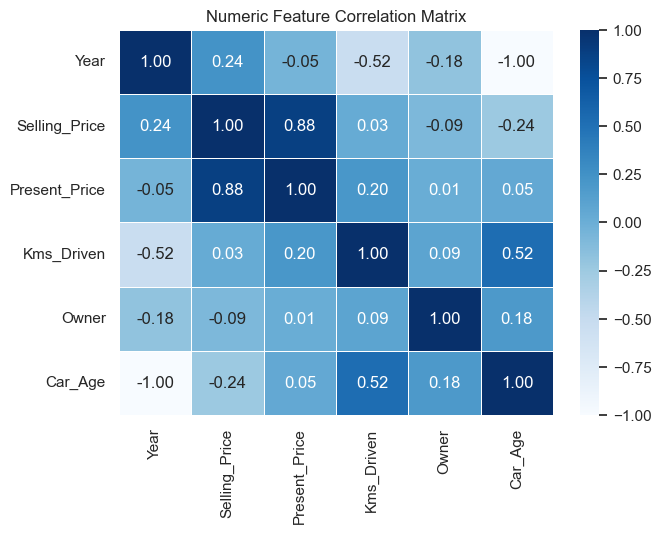

In [2]:
print("Statistical Summary")
display(df.describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], kde=True, color='teal')
plt.title("Distribution of Selling Price")
plt.xlabel("Selling Price (in Lakhs)")

plt.subplot(1, 2, 2)
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title("Selling Price vs. Fuel Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', hue='Fuel_Type', data=df, s=60)
plt.title("Selling Price vs. Car Age")
plt.xlabel("Car Age (Years)")
plt.ylabel("Selling Price (in Lakhs)")
plt.show()

plt.figure(figsize=(7, 5))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Numeric Feature Correlation Matrix")
plt.show()

Training samples: 240, Features: 51
Testing samples:  61

Regression Model Evaluation Summary


,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.218409,1.859728,0.849859
1,Random Forest Regressor,0.605875,0.873419,0.966883


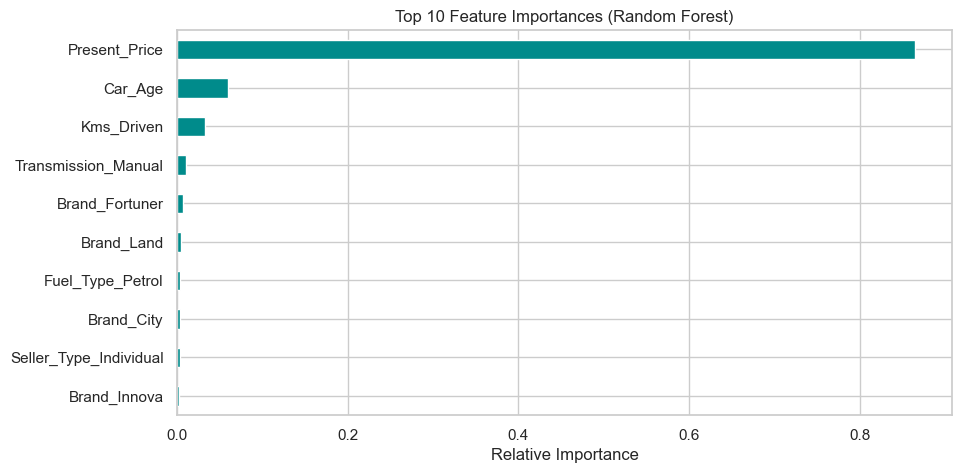

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_model = df.drop(columns=['Car_Name', 'Year'])

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(columns=['Selling_Price'])
y = df_encoded['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}, Features: {X_train.shape[1]}")
print(f"Testing samples:  {X_test.shape[0]}")

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

def compute_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2 Score": r2}

results_df = pd.DataFrame([
    compute_metrics(y_test, y_pred_lr, "Linear Regression"),
    compute_metrics(y_test, y_pred_rf, "Random Forest Regressor")
])

print("\nRegression Model Evaluation Summary")
display(results_df)

feat_importances = pd.Series(rf.feature_importances_, index=X.columns).nlargest(10)

plt.figure(figsize=(10, 5))
feat_importances.plot(kind='barh', color='darkcyan')
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Relative Importance")
plt.gca().invert_yaxis()
plt.show()